## Imports

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

---
## Fonction de simulation

In [19]:
all_dfs = []

# Parameters
E=1
rho=2
L=1

Nt=300
Nx=100
SS=3
nodes = np.arange(SS, Nx-SS)          # grille non paddée : indices dans [0, Nx)
t_end=3

N=6
ndt = 3     # number of dt in the future to predict

AMPLITUDES = np.linspace(0.005, 0.1, N).round(3).tolist()
PULSATIONS = np.linspace(7, 90, N).round(1).tolist()

n_sims = len(AMPLITUDES)*len(PULSATIONS)

for idx, (A, omega) in enumerate(product(AMPLITUDES, PULSATIONS), start=1):
    v = np.sqrt(E/rho)

    x  = np.linspace(0, L, Nx)
    dx = x[1] - x[0]
    dt = t_end / Nt

    CFL = v * dt / dx
    assert CFL <= 1.0, f"CFL={CFL:.3f} > 1 : schéma instable"

    t_pulse = 2 * np.pi / omega

    def u_right(t):
        if t < t_pulse:
            return A * np.sin(omega * t)
        else:
            return 0.0

    u     = np.zeros(Nx)
    u_dot = np.zeros(Nx)
    u_2   = np.zeros(Nx)

    u_storage         = np.zeros((Nt+1, Nx))
    u_dot_storage     = np.zeros((Nt, Nx))
    u_xx_storage      = np.zeros((Nt, Nx))
    delta_u_storage   = np.zeros((Nt, Nx))
    slope_left_store  = np.zeros((Nt, Nx))
    slope_right_store = np.zeros((Nt, Nx))
    rate_slope_left_store  = np.zeros((Nt, Nx))
    rate_slope_right_store = np.zeros((Nt, Nx))

    u_storage[0] = u.copy()

    x_right = np.arange(1, SS+1) * dx
    x_left  = -np.arange(SS, 0, -1) * dx

    rows = []

    # --- Boucle de simulation ---
    for n in range(Nt):
        tn = n * dt

        u_xx = np.zeros(Nx)
        u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2

        u_new = np.zeros(Nx)
        u_new[1:-1] = 2*u[1:-1] - u_2[1:-1] + CFL**2 * (u[2:] - 2*u[1:-1] + u[:-2])
        u_new[0]  = 0
        u_new[-1] = u_right(tn)

        u_dot = np.zeros(Nx)
        u_dot[1:-1] = (u[1:-1] - u_2[1:-1]) / dt

        u_dot_storage[n]   = u_dot
        u_xx_storage[n]    = u_xx
        delta_u_storage[n] = u_new - u

        # --- Pentes gauche/droite : vectorisation (même logique que Y_left / Y_right) ---
        Y_left  = u[nodes[None, :] + np.arange(-SS, 0)[:, None]]    # (SS, n_nodes)
        Y_right = u[nodes[None, :] + np.arange(1, SS+1)[:, None]]   # (SS, n_nodes)

        slope_left_store[n,  nodes] = np.polyfit(x_left,  Y_left,  1)[0]
        slope_right_store[n, nodes] = np.polyfit(x_right, Y_right, 1)[0]

        # --- Taux de variation des pentes : différence entre deux tranches stockées ---
        if n >= ndt:
            rate_slope_left_store[n,  nodes]  = (slope_left_store[n,  nodes]  - slope_left_store[n-ndt,  nodes])  / (ndt*dt)
            rate_slope_right_store[n, nodes]  = (slope_right_store[n, nodes]  - slope_right_store[n-ndt, nodes]) / (ndt*dt)

        u_2 = u.copy()
        u   = u_new
        u_storage[n+1] = u.copy()

    for n in range(ndt, Nt-ndt-1):
        rows.append(pd.DataFrame({
            "A":       A,
            "omega":   omega,
            "n_step":  n,
            "u_dot":   u_dot_storage[n, nodes],
            "u_xx":    u_xx_storage[n,  nodes],
            "ux-":     slope_left_store[n,  nodes],
            "ux+":     slope_right_store[n, nodes],
            "ux-_dot": rate_slope_left_store[n,  nodes],
            "ux+_dot": rate_slope_right_store[n, nodes],
            "delta_u": u_storage[n+ndt, nodes] - u_storage[n, nodes],
        }))

    all_dfs.append(pd.concat(rows, ignore_index=True))

# We concatenate each simulation in the df which is the full dataset table
df = pd.concat(all_dfs, ignore_index=True)
print(df.head(0))

Empty DataFrame
Columns: [A, omega, n_step, u_dot, u_xx, ux-, ux+, ux-_dot, ux+_dot, delta_u]
Index: []



## Split train / val / test

In [20]:
rng = np.random.default_rng(seed=42)

steps   = np.sort(df["n_step"].unique())
n_steps = len(steps)

n_train = int(0.70 * n_steps)
n_val   = int(0.15 * n_steps)

train_steps = set(steps[:n_train])
val_steps   = set(steps[n_train:n_train + n_val])

def assign_split(row):
    if row["n_step"] in train_steps: return "train"
    if row["n_step"] in val_steps:   return "val"
    return "test"

df["split"] = df.apply(assign_split, axis=1)

print("Split distribution:")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:5s} : {n:>8,} rows  ({100*n/len(df):.1f} %)")

Split distribution:
  train :  693,720 rows  (70.0 %)
  val   :  145,512 rows  (14.7 %)
  test  :  152,280 rows  (15.4 %)


## Normalisation (z-score)

In [21]:
INPUTS = ["u_dot","u_xx","ux-","ux+"]
OUTPUTS = ["delta_u"]

# Masque train pour calculer les stats uniquement sur le train set
train_mask = df["split"] == "train"

# Calcul des stats sur le train set uniquement
norm_stats = pd.DataFrame({
    "mean": df.loc[train_mask, INPUTS + OUTPUTS].mean(),
    "std" : df.loc[train_mask, INPUTS + OUTPUTS].std(),
})
norm_stats["std"] = norm_stats["std"].replace(0, 1)  # éviter division par 0

# Application à tout le dataset
for col in INPUTS + OUTPUTS:
    df[col + "_n"] = (df[col] - norm_stats.loc[col, "mean"]) / norm_stats.loc[col, "std"]

print("Statistiques de normalisation (calculées sur train) :")
print(norm_stats.round(6))

Statistiques de normalisation (calculées sur train) :
             mean        std
u_dot   -0.001074   0.552733
u_xx     0.012515  80.781888
ux-      0.000056   0.669745
ux+      0.000482   0.661549
delta_u -0.000029   0.013902


---
## Sauvegarde

In [22]:
COLS_ORDER = (
    INPUTS                                   # inputs bruts
    + [c + "_n" for c in INPUTS]             # inputs normalisés
    + OUTPUTS                                # outputs bruts
    + [c + "_n" for c in OUTPUTS]            # outputs normalisés
    + ["split"]
)
df = df[COLS_ORDER]

# Dataset
df.to_csv("wave_beam_dataset.csv", index=False)
print(f"Dataset sauvegardé : wave_beam_dataset.csv")
print(f"  {len(df):,} lignes × {len(df.columns)} colonnes")

# Stats de normalisation — à recharger dans les fichiers 2 et 3
norm_stats.to_csv("norm_stats.csv")
print(f"Stats de normalisation sauvegardées : norm_stats.csv")

Dataset sauvegardé : wave_beam_dataset.csv
  991,512 lignes × 11 colonnes
Stats de normalisation sauvegardées : norm_stats.csv


In [23]:
import json

params_simulation = {
    "L"          : L,
    "Nx"         : Nx,
    "Nt"         : Nt,
    "t_end"      : t_end,
    "E": E,
    "rho":rho,
    "AMPLITUDES" : AMPLITUDES,
    "PULSATIONS" : PULSATIONS,
    "n_sims"     : n_sims,
    "SS":SS,
    "INPUTS":INPUTS,
    "OUTPUTS":OUTPUTS,
}

with open("params_simulation.json", "w") as f:
    json.dump(params_simulation, f, indent=2)

print("Paramètres sauvegardés : params_simulation.json")

Paramètres sauvegardés : params_simulation.json


# 02 — Entraînement du réseau


In [24]:
import numpy as np
import json

with open("params_simulation.json") as f:
    p = json.load(f)

L, Nx, Nt,t_end  = p["L"], p["Nx"], p["Nt"], p["t_end"]
AMPLITUDES    = p["AMPLITUDES"]
PULSATIONS    = p["PULSATIONS"]
n_sims        = p["n_sims"]
E   = p["E"]
rho = p["rho"]
v   = np.sqrt(E / rho)
SS=p["SS"]

INPUTS=p["INPUTS"]
OUTPUTS=p["OUTPUTS"]

---
## 1. Paramètres

In [25]:
# Fichiers produits par le notebook 01
DATASET_FILE   = "wave_beam_dataset.csv"
NORMSTATS_FILE = "norm_stats.csv"

# Architecture du réseau
HIDDEN_SIZE = 50    # nombre de neurones par couche cachée
N_LAYERS    = 3     # nombre de couches cachées

# Entraînement
LEARNING_RATE = 1e-3
N_EPOCHS      = 10
BATCH_SIZE    = 512

---
## 2. Chargement des données

In [26]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Chargement du dataset et des stats de normalisation
df         = pd.read_csv(DATASET_FILE)
norm_stats = pd.read_csv(NORMSTATS_FILE, index_col=0)

#To check and visualise
print(f"Dataset : {len(df):,} lignes")
print(f"Splits  : {df['split'].value_counts().to_dict()}")

# Colonnes normalisées
INPUTS_N = [f"{x}_n" for x in INPUTS]
OUTPUTS_N = [f"{x}_n" for x in OUTPUTS]

# Extraction train / val en utilisant la colonne split du dataset
train_mask = df["split"] == "train"
val_mask   = df["split"] == "val"

X_train = df.loc[train_mask, INPUTS_N].values.astype(np.float32)
y_train = df.loc[train_mask, OUTPUTS_N].values.astype(np.float32)

X_val   = df.loc[val_mask, INPUTS_N].values.astype(np.float32)
y_val   = df.loc[val_mask, OUTPUTS_N].values.astype(np.float32)

print(f"\nTrain : {len(X_train):,} exemples")
print(f"Val   : {len(X_val):,} exemples")

# Conversion en tenseurs PyTorch et création des DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=BATCH_SIZE
)

Dataset : 991,512 lignes
Splits  : {'train': 693720, 'test': 152280, 'val': 145512}

Train : 693,720 exemples
Val   : 145,512 exemples


---
## 3. Network defintion


In [27]:
class Reseau(nn.Module):

    def __init__(self, n_inputs, n_outputs, hidden_size, n_layers):
        super().__init__()

        couches = []
        taille_entree = n_inputs

        for _ in range(n_layers):
            couches.append(nn.Linear(taille_entree, hidden_size, bias=False))  # couche linéaire
            couches.append(nn.Tanh())                              # activation non-linéaire
            taille_entree = hidden_size

        couches.append(nn.Linear(hidden_size, n_outputs, bias=False))  # couche de sortie

        self.reseau = nn.Sequential(*couches)

    def forward(self, x):
        return self.reseau(x)


modele = Reseau(
    n_inputs    = len(INPUTS_N), 
    n_outputs   = len(OUTPUTS_N),   
    hidden_size = HIDDEN_SIZE,
    n_layers    = N_LAYERS,
)

n_params = sum(p.numel() for p in modele.parameters())
print(modele)
print(f"\nNombre de paramètres : {n_params:,}")

Reseau(
  (reseau): Sequential(
    (0): Linear(in_features=4, out_features=50, bias=False)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=50, bias=False)
    (3): Tanh()
    (4): Linear(in_features=50, out_features=50, bias=False)
    (5): Tanh()
    (6): Linear(in_features=50, out_features=1, bias=False)
  )
)

Nombre de paramètres : 5,250


---
## 4. Training

Epoch    2/10  —  train: 0.0623  |  val: 0.1562  
Epoch    4/10  —  train: 0.0551  |  val: 0.1316  
Epoch    6/10  —  train: 0.0524  |  val: 0.1176  
Epoch    8/10  —  train: 0.0502  |  val: 0.1450  
Epoch   10/10  —  train: 0.0488  |  val: 0.1547  


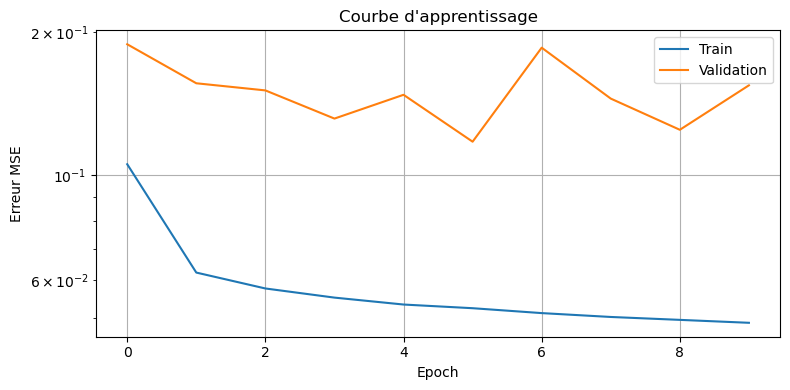

Meilleur modèle rechargé — val minimale : 0.117628


In [28]:
criterion  = nn.MSELoss()   # erreur quadratique moyenne
optimiseur = torch.optim.Adam(modele.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiseur, mode="min", factor=0.5, patience=10
)

historique_train = []
historique_val   = []

meilleure_val = float("inf")   # on initialise au pire score possible
patience_compteur = 0          # on verra ça après

for epoch in range(1, N_EPOCHS + 1):

    # Phase entraînement
    modele.train()
    perte_train = 0.0       #initialisation of training loss
    for X_batch, y_batch in train_loader:
        optimiseur.zero_grad()                       # remet les gradients à zéro
        prediction = modele(X_batch)                 # prédiction
        perte      = criterion(prediction, y_batch)  # erreur
        perte.backward()                             # rétropropagation
        optimiseur.step()                            # mise à jour des poids
        perte_train += perte.item()
    perte_train /= len(train_loader)

    # Phase validation : un seul forward pass sur tout le val
    modele.eval()
    with torch.no_grad():
        pred_val = modele(torch.tensor(X_val)).numpy()

    # Loss globale 
    perte_val = ((pred_val - y_val)**2).mean()
    scheduler.step(perte_val)

    # Loss par output
    historique_train.append(perte_train)
    historique_val  .append(perte_val)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:4d}/{N_EPOCHS}  —  "
            f"train: {perte_train:.4f}  |  "
            f"val: {perte_val:.4f}  ")
    
    # Si la val s'est améliorée, on sauvegarde ce modèle
    if perte_val < meilleure_val:
        meilleure_val = perte_val
        torch.save(modele.state_dict(), "model.pth")   # on écrase avec le meilleur

# Courbe d'apprentissage
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(historique_train, label="Train")
ax.plot(historique_val,   label="Validation")
ax.set_xlabel("Epoch") ; ax.set_ylabel("Erreur MSE")
ax.set_title("Courbe d'apprentissage")
ax.set_yscale("log")
ax.legend() ; ax.grid(True)
plt.tight_layout() ; plt.show()

# On recharge le meilleur modèle trouvé pendant l'entraînement
modele.load_state_dict(torch.load("model.pth",weights_only=True ))
print(f"Meilleur modèle rechargé — val minimale : {meilleure_val:.6f}")

---
## Vérification

Évaluation sur 152,280 échantillons test


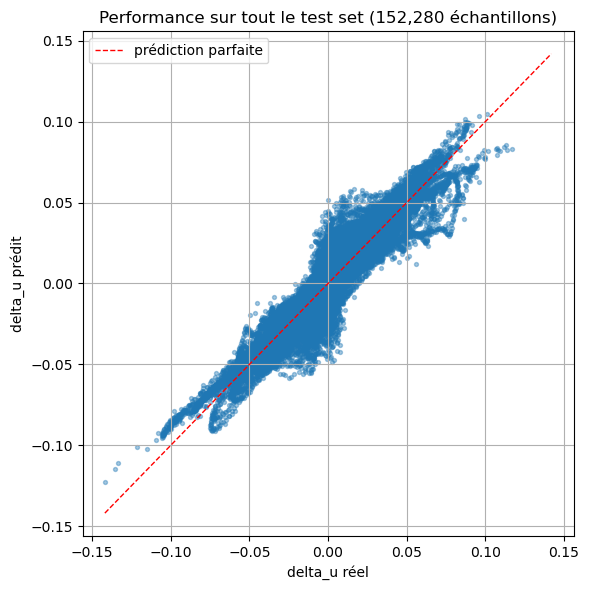

MSE : 2.1961e-05   |   R² : 0.8926


In [29]:
# --- 1. Filtrer les lignes test du dataset ---
df_test = df[df["split"] == "test"].reset_index(drop=True)
print(f"Évaluation sur {len(df_test):,} échantillons test")

# --- 2. Extraire entrées (déjà normalisées dans le CSV) et sortie réelle ---
X_new  = df_test[[c + "_n" for c in INPUTS]].values.astype(np.float32)
y_true = df_test["delta_u"].values                          # vérité terrain non normalisée

# --- 3. Prédiction ---
modele.eval()
with torch.no_grad():
    y_pred_n = modele(torch.tensor(X_new)).numpy().squeeze()

# Dénormalisation de la sortie
mean_du = norm_stats.loc["delta_u", "mean"]
std_du  = norm_stats.loc["delta_u", "std"]
y_pred = y_pred_n * std_du + mean_du

# --- 4. Visualisation ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true, y_pred, alpha=0.4, s=8)
lim = max(abs(y_true).max(), abs(y_pred).max())
ax.plot([-lim, lim], [-lim, lim], "r--", lw=1, label="prédiction parfaite")
ax.set_xlabel("delta_u réel")
ax.set_ylabel("delta_u prédit")
ax.set_title(f"Performance sur tout le test set ({len(df_test):,} échantillons)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

mse = ((y_pred - y_true)**2).mean()
r2  = 1 - mse / y_true.var()
print(f"MSE : {mse:.4e}   |   R² : {r2:.4f}")

0.0012533750013972167
0.22081583399994997


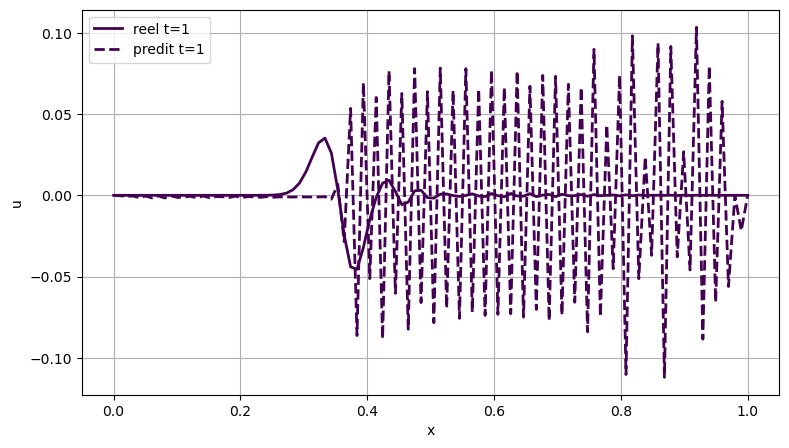

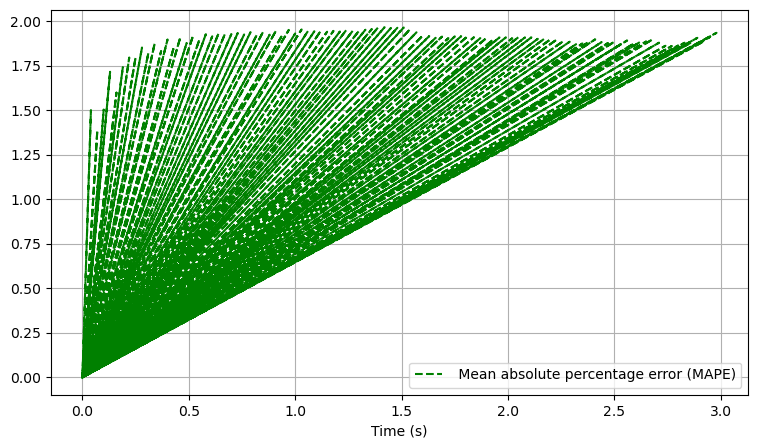

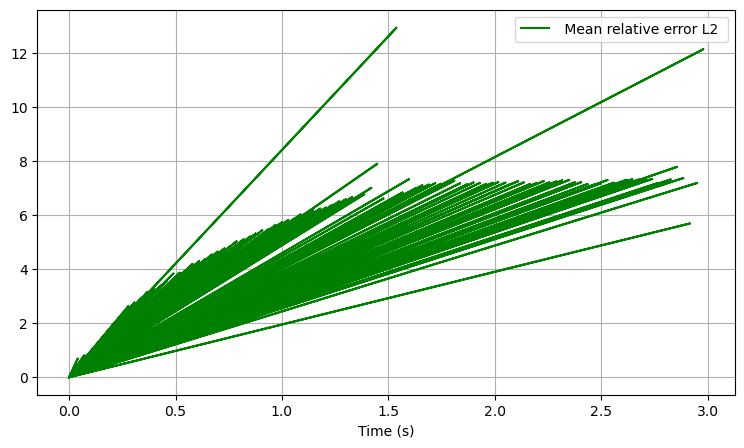

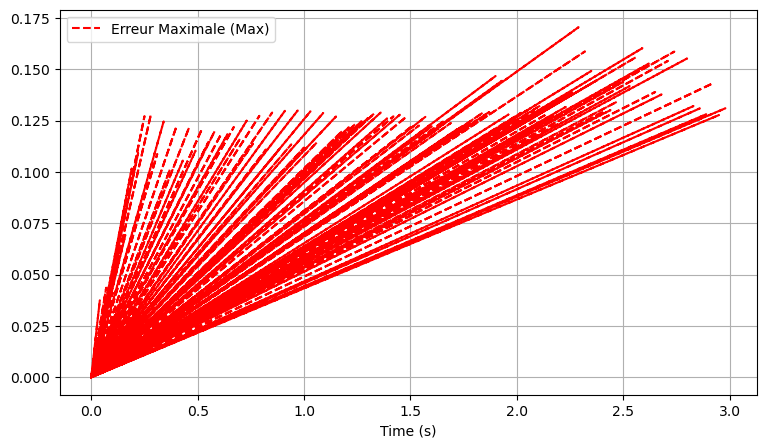

In [ ]:
import time
# Roll out cell

A = AMPLITUDES[2]
omega = PULSATIONS[2]
dx = L / (Nx - 1)
dt = t_end / Nt
#t_list = [0.5, 0.9, 1.5]
t_list = [1]
x = np.linspace(0, L, Nx)

stats_normalisation = {}
for name in INPUTS + OUTPUTS:
    stats_normalisation[name] = {
        "mean": norm_stats.loc[name, "mean"],
        "std" : norm_stats.loc[name, "std"]
    }

mu_du = stats_normalisation[OUTPUTS[0]]["mean"]
sd_du = stats_normalisation[OUTPUTS[0]]["std"]

noms_features = [c[:-2] for c in INPUTS_N]   

t_pulse = 2 * np.pi / omega
def u_right(t):
    return A * np.sin(omega * t) if t < t_pulse else 0.0

# Abscisses des stencils, identiques au dataset
x_left  = -np.arange(SS, 0, -1) * dx     # offsets -SS..-1
x_right =  np.arange(1, SS+1)   * dx     # offsets +1..+SS

def pentes(u_vec, noeuds):
    ux_m = np.zeros(Nx)
    ux_p = np.zeros(Nx)
    for j in noeuds:
        y_left  = u_vec[j-SS : j]
        y_right = u_vec[j+1 : j+SS+1]
        ux_m[j], _ = np.polyfit(x_left,  y_left,  deg=1)
        ux_p[j], _ = np.polyfit(x_right, y_right, deg=1)
    return ux_m, ux_p

def construire_entree(champs, noeuds):
    e = np.zeros((len(noeuds), len(noms_features)), dtype=np.float32)
    for idx, name in enumerate(noms_features):
        mu = stats_normalisation[name]["mean"]
        sd = stats_normalisation[name]["std"]
        e[:, idx] = (champs[name][noeuds] - mu) / sd
    return e

# =====================================================
# 1) VRAIE simulation (physique)
# =====================================================

v   = np.sqrt(E / rho)
CFL = v * dt / dx

u   = np.zeros(Nx)
u_2 = np.zeros(Nx)
reel = {0.0: u.copy()}

start_time_phys = time.perf_counter()

for n in range(Nt):
    t = n * dt
    u_new = np.zeros(Nx)
    u_new[1:-1] = 2*u[1:-1] - u_2[1:-1] + CFL**2 * (u[2:] - 2*u[1:-1] + u[:-2])
    u_new[0]  = 0.0
    u_new[-1] = u_right(t+dt)
    u_2 = u.copy()
    u   = u_new
    reel[round((n+1)*dt, 5)] = u.copy()

time_phys = time.perf_counter() - start_time_phys

# =====================================================
# 2) Simulation PREDITE (reseau)
# =====================================================

start_time_pred = time.perf_counter()

u   = np.zeros(Nx)
u_ndt = np.zeros(Nx)
pred = {0.0: u.copy()}

# Error initialisation

error_mape=np.zeros(Nt)
error_max=np.zeros(Nt)
error_l2_rel=np.zeros(Nt)

def l2_rel(u_pred, u_reel, eps=1e-12):
    return np.linalg.norm(u_pred - u_reel) / (np.linalg.norm(u_reel) + eps)

def smape (prediction, cible,eps=1e-12):
    mask = cible!= 0
    num=np.abs(cible[mask]-prediction[mask])*2
    den=np.abs(cible[mask]) +np.abs(prediction[mask])+eps
    return np.mean((num/den))

def errormax(cible, prediction,eps=1e-12):
    num = np.abs(cible-prediction)
    #den = np.maximum(np.abs(cible), eps)
    den = 1
    return np.max((num/den))


temps_sim=np.zeros(Nt)

valid = np.arange(SS, Nx - SS)              # noeuds predits
band  = np.r_[1:SS, Nx-SS:Nx-1]             # noeuds interieurs non couverts

# # Biais au repos (toutes features nulles)
# champs_repos = {name: np.zeros(Nx) for name in noms_features}
# with torch.no_grad():
#     sortie_repos = modele(torch.tensor(construire_entree(champs_repos, valid))).numpy().ravel()
# bias_repos = (sortie_repos * sd_du + mu_du)[0]   # scalaire

ux_m_storage  = np.zeros((Nt, Nx))
ux_p_storage  = np.zeros((Nt, Nx))


for n in range(ndt, Nt, ndt):
    t = n * dt
    t_suivant = round((n+1)*dt,5)

    u_xx = np.zeros(Nx)
    u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    u_dot = (u - u_ndt) / (ndt*dt)                       
    
    ux_m, ux_p = pentes(u, valid)

    ux_m_storage[n,:]  = ux_m
    ux_p_storage[n,:]  = ux_p

    if n>=ndt:
        ux_p_dot = (ux_p-ux_p_storage[n-ndt,:])/(ndt*dt)
        ux_m_dot = (ux_m-ux_m_storage[n-ndt,:])/(ndt*dt)
    else:
        ux_p_dot=np.zeros(Nx)
        ux_m_dot=np.zeros(Nx)

    champs = {"u_dot": u_dot, "u_xx": u_xx, "ux-": ux_m, "ux+": ux_p,"ux-_dot": ux_m_dot, "ux+_dot": ux_p_dot,}

    with torch.no_grad():
        sortie = modele(torch.tensor(construire_entree(champs, valid))).numpy().ravel()
    delta_u = sortie * sd_du + mu_du 

    u_new = u.copy()

    u_new[valid] = u[valid] + delta_u

    # Bande non couverte : repli physique
    u_new[band] = (2*u[band] - u_ndt[band] + CFL**2 * (u[band+1] - 2*u[band] + u[band-1]))

    u_new[0]  = 0.0

    u_new[-1] = u_right(t+dt)

    u_ndt = u.copy()

    u   = u_new

    pred[t_suivant] = u.copy()

    u_reel_instante=reel[t_suivant]

    # Error computing

    error_mape[n] = smape(u_new, u_reel_instante).mean()

    error_max[n] = errormax(u_new, u_reel_instante)
    
    error_l2_rel[n] = l2_rel(u_new, u_reel_instante)

    temps_sim[n]=t_suivant

time_pred = time.perf_counter() - start_time_pred


# =====================================================
# 3) Trace
# =====================================================
print(time_phys)
print(time_pred)

print( "ndt = ", ndt)

plt.figure(figsize=(9, 5))
for t, c in zip(t_list, plt.cm.viridis(np.linspace(0, 0.85, len(t_list)))):
    kr = min(reel, key=lambda k: abs(k - t))
    kp = min(pred, key=lambda k: abs(k - t))
    plt.plot(x, reel[kr], color=c, lw=2, label=f"reel t={t}")
    plt.plot(x, pred[kp], color=c, lw=2, ls="--", label=f"predit t={t}")

plt.xlabel("x"); plt.ylabel("u"); plt.legend(); plt.grid(True)
plt.show()

# Plotting errors

plt.figure(figsize=(9, 5))
plt.plot(temps_sim,error_mape, label=" Mean absolute percentage error (MAPE)", color="green", lw=1.5, ls="--")
plt.legend()
plt.grid(True)
plt.xlabel("Time (s)")

plt.figure(figsize=(9, 5))
plt.plot(temps_sim,error_l2_rel, label=" Mean relative error L2 ", color="green", lw=1.5, ls="-")
plt.legend()
plt.grid(True)
plt.xlabel("Time (s)")

plt.figure(figsize=(9, 5))
plt.plot(temps_sim, error_max, label="Erreur Maximale (Max)", color="red", lw=1.5, ls="--")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

plt.show()

